**# Core Engineering & Analitycal Concepts**

General configuration

In [1]:
import sys
import subprocess
import importlib

REQUIRED_PACKAGES =  [
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "sqlalchemy",
    "mysql-connector-python"
]

def install_packages(packages):
    for package in packages:
        module_name = package
        
        if package == "scikit-learn":
            module_name = "sklearn"
        elif package == "mysql-connector-python":
            module_name = "mysql.connector"
        
        try:
            importlib.import_module(module_name)
            print(f"Package already install {package}")
        except ImportError:
            print(f"Package not found. Installing {package}")
            cmd = [sys.executable, "-m", "pip", "install", package]
            result = subprocess.run(cmd, capture_output=True, text=True)
            if result.returncode == 0:
                print(f"Successfully Installed {package}")
            else:
                print(f"Failed to install {package}")
    
install_packages(REQUIRED_PACKAGES)

Package already install numpy
Package already install pandas
Package already install scipy
Package already install matplotlib
Package already install seaborn
Package already install scikit-learn
Package already install sqlalchemy
Package already install mysql-connector-python


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else "default")

PALETTE = {
    'navy': '#1D3557',
    'coral': '#E63946',
    'steel_blue': '#457B9D',
    'cyan': '#A8DADC',
    'sand': '#F1FAEE'
}

In [3]:
%matplotlib inline
%matplotlib widget

Data Extraction from MySQL

In [4]:
USER = os.getenv('DB_USER')
PASS = os.getenv('DB_PASSWORD')
HOST = os.getenv('DB_HOST')
PORT = os.getenv('DB_PORT')
DB = os.getenv('DB_NAME')

conn = f"mysql+pymysql://{USER}:{PASS}@{HOST}:{PORT}/{DB}"
engine = create_engine(conn)

query = """
SELECT
    f.report_id,
    f.`Aircraft Registration`,
    d_occ.complete_date AS ocurrence_date,
    d_rep.complete_date AS report_date,
    o.operator_Code,
    a.`Aircraft Manufacturer`,
    a.`Aircraft Group Code`
FROM sdr.fact_sdr_reports f
LEFT JOIN sdr.dim_date d_occ ON f.occurrence_date_id = d_occ.date_id
LEFT JOIN sdr.dim_date d_rep ON f.report_date_id = d_rep.date_id
LEFT JOIN sdr.dim_operator o ON f.operator_id = o.operator_id
LEFT JOIN sdr.dim_aircraft a ON f.aircraft_id = a.aircraft_id;
"""

In [5]:
df = pd.read_sql(query, con=engine)
df

,report_id,Aircraft Registration,ocurrence_date,report_date,operator_Code,Aircraft Manufacturer,Aircraft Group Code
0,1,642UA,2025-06-30,2025-07-02,CALA,BOEING,767322
1,2,648JB,2025-07-03,2025-07-03,YENA,AIRBUS,A32023
2,3,649JB,2025-07-03,2025-07-03,YENA,AIRBUS,A32023
3,4,57857,2025-07-03,2025-07-07,CALA,BOEING,757324
4,5,271NV,2025-07-03,2025-07-07,WX0A,AIRBUS,A32021
...,...,...,...,...,...,...,...
275,276,28478,2026-06-18,2026-06-19,CALA,BOEING,737924
276,277,17436,2026-06-18,2026-06-22,CALA,BOEING,7379
277,278,755PM,2026-06-19,2026-06-23,2026,PILATS,PC1247
278,279,934XJ,2026-06-18,2026-06-24,REXA,CNDAIR,CL6002


Standarization

In [6]:
df.dtypes

report_id                 int64
Aircraft Registration       str
ocurrence_date           object
report_date              object
operator_Code               str
Aircraft Manufacturer       str
Aircraft Group Code         str
dtype: object

In [7]:
df['ocurrence_date'] =  pd.to_datetime(df['ocurrence_date'])
df['report_date'] =  pd.to_datetime(df['report_date'])

In [8]:
df.dtypes

report_id                        int64
Aircraft Registration              str
ocurrence_date           datetime64[s]
report_date              datetime64[s]
operator_Code                      str
Aircraft Manufacturer              str
Aircraft Group Code                str
dtype: object

In [9]:
ooc_monthly = (
    df.set_index('ocurrence_date')
    .resample('ME')
    .size()
    .rename('occurrences')
)

rep_monthly = (
    df.set_index('report_date')
    .resample('ME')
    .size()
    .rename('reports')
)

df_monthly = pd.concat([ooc_monthly, rep_monthly], axis=1).fillna(0).astype(int)
df_monthly


,occurrences,reports
2025-06-30,1,0
2025-07-31,13,13
2025-08-31,19,14
2025-09-30,23,26
2025-10-31,46,48
2025-11-30,22,20
2025-12-31,24,24
2026-01-31,29,23
2026-02-28,21,26
2026-03-31,21,19


In [10]:
df_monthly['year'] = df_monthly.index.year
df_monthly['month'] = df_monthly.index.month

df_monthly

,occurrences,reports,year,month
2025-06-30,1,0,2025,6
2025-07-31,13,13,2025,7
2025-08-31,19,14,2025,8
2025-09-30,23,26,2025,9
2025-10-31,46,48,2025,10
2025-11-30,22,20,2025,11
2025-12-31,24,24,2025,12
2026-01-31,29,23,2026,1
2026-02-28,21,26,2026,2
2026-03-31,21,19,2026,3


Statistical Concepts

In [11]:
skew_occ = stats.skew(df_monthly['occurrences'])
skew_rep = stats.skew(df_monthly['reports'])

kurt_occ = stats.kurtosis(df_monthly['occurrences'])
kurt_rep = stats.kurtosis(df_monthly['reports'])

stats_occ, p_val_occ = stats.shapiro(df_monthly['occurrences'])
stats_rep, p_val_rep = stats.shapiro(df_monthly['reports'])

# Summary
normality_summary = pd.DataFrame(
    {
        'Metric': ['Occurences', 'Reports'],
        'Mean': [df_monthly['occurrences'].mean(), df_monthly['reports'].mean()],
        'Std Dev': [df_monthly['occurrences'].std(), df_monthly['reports'].std()],
        'Skewness': [skew_occ, skew_rep],
        'Kurtosis': [kurt_occ, kurt_rep],
        'Shapiro-Wilk W': [stats_occ, stats_rep],
        'p-value': [p_val_occ, p_val_rep],
        'Normally Ditributed (alpha=0.05)?': [p_val_occ > 0.05, p_val_rep >0.05]
    }
)

display(normality_summary)

,Metric,Mean,Std Dev,Skewness,Kurtosis,Shapiro-Wilk W,p-value,Normally Ditributed (alpha=0.05)?
0,Occurences,21.538462,10.477081,0.367073,1.184922,0.921514,0.262917,True
1,Reports,21.538462,11.170015,0.536493,1.221172,0.934469,0.389362,True


Distribution visualization

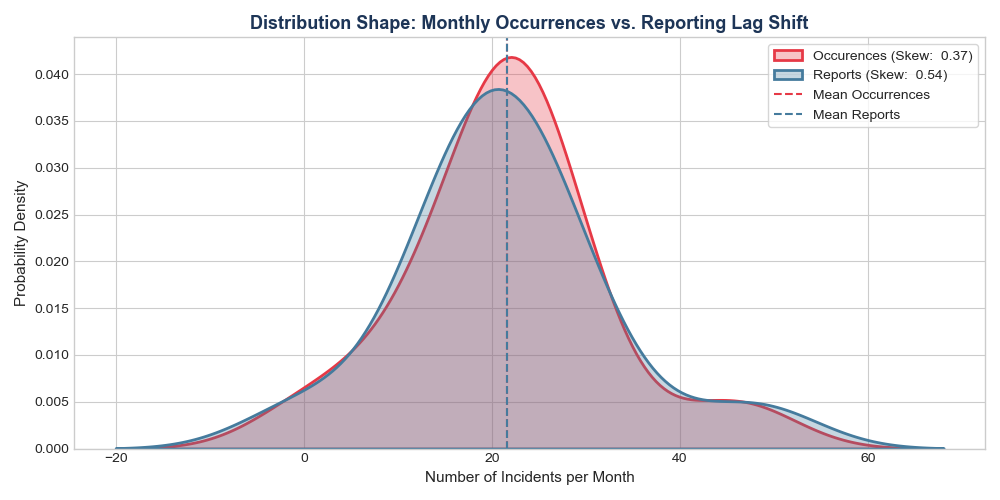

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))


sns.kdeplot(
    df_monthly['occurrences'],
    color=PALETTE['coral'],
    label=f"Occurences (Skew: {skew_occ: .2f})",
    fill=True,
    alpha=0.3,
    linewidth=2,
    ax=ax
)

sns.kdeplot(
    df_monthly['reports'],
    color=PALETTE['steel_blue'],
    label=f"Reports (Skew: {skew_rep: .2f})",
    fill=True,
    alpha=0.3,
    linewidth=2,
    ax=ax
)

ax.axvline(df_monthly['occurrences'].mean(), color=PALETTE['coral'], linestyle= '--', linewidth=1.5, label="Mean Occurrences")
ax.axvline(df_monthly['reports'].mean(), color=PALETTE['steel_blue'], linestyle= '--', linewidth=1.5, label="Mean Reports")
ax.set_title("Distribution Shape: Monthly Occurrences vs. Reporting Lag Shift", fontsize=13, fontweight='bold', color=PALETTE['navy'])
ax.set_xlabel("Number of Incidents per Month", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()



In [13]:
def compute_ci_95(series, name="Metric"):
    n = len(series)
    df_deg = n - 1
    mean = series.mean()
    s = series.std(ddof=1)
    sem = s/np.sqrt(n)
    
    t_critical = stats.t.ppf(1-0.05/2, df=df_deg)
    
    margin_of_error = t_critical * sem
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error
    return {
        'Metric': name,
        'Sample Size (N)': n,
        'Degrees of Freedom (df)': df_deg,
        'Sample Mean (x̄)': mean,
        'Std Dev (s)': s,
        'Std Error (SEM)': sem,
        't-Critical (t*)': t_critical,
        'Margin of Error (±)': margin_of_error,
        'CI Lower (95%)': ci_lower,
        'CI Upper (95%)': ci_upper
    }
    
ci_occ = compute_ci_95(df_monthly['occurrences'], name='Occurrences')
ci_rep = compute_ci_95(df_monthly['reports'], name='Reports')

df_ci = pd.DataFrame([ci_occ, ci_rep])
display(df_ci)   
    

,Metric,Sample Size (N),Degrees of Freedom (df),Sample Mean (x̄),Std Dev (s),Std Error (SEM),t-Critical (t*),Margin of Error (±),CI Lower (95%),CI Upper (95%)
0,Occurrences,13,12,21.538462,10.477081,2.905820,2.178813,6.331237,15.207225,27.869698
1,Reports,13,12,21.538462,11.170015,3.098005,2.178813,6.749972,14.788489,28.288434


In [14]:
occ_2025 = df_monthly[df_monthly['year'] == 2025]['occurrences']
occ_2026 = df_monthly[df_monthly['year'] == 2026]['occurrences']

n_2025, mean_2025, std_2025 = len(occ_2025), occ_2025.mean(), occ_2025.std(ddof=1)
n_2026, mean_2026, std_2026 = len(occ_2026), occ_2026.mean(), occ_2026.std(ddof=1)

t_stat, p_value = stats.ttest_ind(
    occ_2026,
    occ_2025,
    equal_var=False,
    alternative='less'
)

se1 =  (std_2026**2) / n_2026
se2 = (std_2025**2) / n_2025

df_welch = ((se1 + se2)**2) / ((se1**2)/(n_2026-1) + (se2**2)/(n_2025-1))

alpha = 0.05
t_crit = stats.t.ppf(alpha, df=df_welch)

test_results = pd.DataFrame(
    [
        {
            '2025 Baseline Mean': round(mean_2025, 2),
            '2026 Post Mean': round(mean_2026, 2),
            'Mean Difference (2026 - 2025)': round(mean_2026 - mean_2025, 2),
            'Welch df': round(df_welch, 2),
            't-Statistic': round(t_stat, 4),
            't-Critical (alpha=0.05)': round(t_crit, 4),
            'p-value': round(p_value, 4),
            'Reject H0 (Statistically Significant)?': p_value < alpha  
        }
    ]
)

print(test_results.to_string(index=False))



 2025 Baseline Mean  2026 Post Mean  Mean Difference (2026 - 2025)  Welch df  t-Statistic  t-Critical (alpha=0.05)  p-value  Reject H0 (Statistically Significant)?
              21.14            22.0                           0.86      8.84       0.1486                  -1.8369   0.5574                                   False


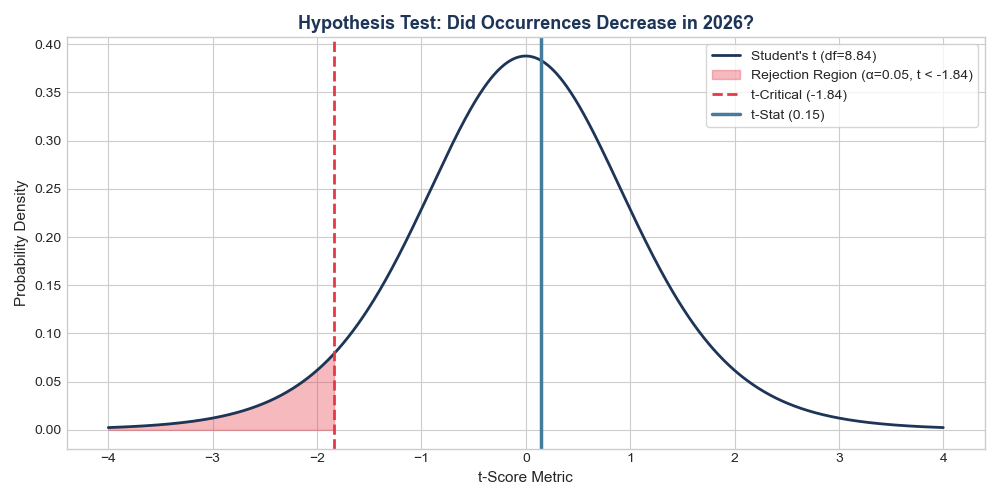

In [15]:
x_vals = np.linspace(-4,4,1000)
y_vals = stats.t.pdf(x_vals, df=df_welch)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, y_vals, color='#1D3557', linewidth=2, label=f"Student's t (df={df_welch:.2f})")

x_reject = np.linspace(-4, t_crit, 500)
y_reject = stats.t.pdf(x_reject, df=df_welch)
ax.fill_between(x_reject, y_reject, color='#E63946', alpha=0.35, label=f'Rejection Region (α=0.05, t < {t_crit:.2f})')

ax.axvline(t_crit, color='#E63946', linestyle='--', linewidth=2, label=f't-Critical ({t_crit:.2f})')
ax.axvline(t_stat, color='#457B9D', linestyle='-', linewidth=2.5, label=f't-Stat ({t_stat:.2f})')

ax.set_title("Hypothesis Test: Did Occurrences Decrease in 2026?", fontsize=13, fontweight='bold', color='#1D3557')
ax.set_xlabel("t-Score Metric", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()



Linear Regression

In [21]:
x = df_monthly['occurrences'].values
y = df_monthly['reports'].values

n = len(x)
k = 1

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)

r_squared = r_value**2
r_squared_adj = 1 -  (((1- r_squared)*(n-1))/(n-k-1))

y_pred = intercept + slope*x
residuals = y- y_pred

residual_se = np.sqrt(np.sum(residuals**2)/(n-2))

regression_summary = pd.DataFrame([{
    'Observations (N)': n,
    'Slope (β1)': round(slope, 4),
    'Intercept (β0)': round(intercept, 4),
    'Pearson r': round(r_value, 4),
    'R-squared (R²)': round(r_squared, 4),
    'Adjusted R²': round(r_squared_adj, 4),
    'Residual Std Error': round(residual_se, 4),
    'Regression p-value': round(p_value_reg, 6),
    'Statistically Significant (p < 0.05)?': p_value_reg < 0.05
}])

print("Linear Regression Diagnostic Summary:")
print(regression_summary.to_string(index=False))



Linear Regression Diagnostic Summary:
 Observations (N)  Slope (β1)  Intercept (β0)  Pearson r  R-squared (R²)  Adjusted R²  Residual Std Error  Regression p-value  Statistically Significant (p < 0.05)?
               13      1.0084         -0.1799     0.9458          0.8945       0.8849              3.7888            0.000001                                   True


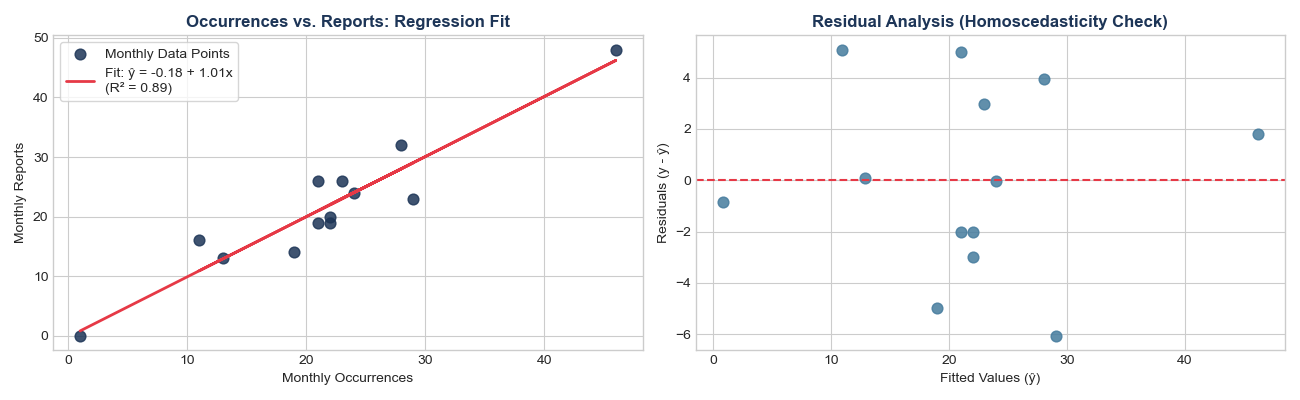

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Scatter plot and fitted regression line
ax1.scatter(x, y, color='#1D3557', s=60, alpha=0.85, label='Monthly Data Points')
ax1.plot(x, y_pred, color='#E63946', linewidth=2, 
         label=f'Fit: ŷ = {intercept:.2f} + {slope:.2f}x\n(R² = {r_squared:.2f})')

ax1.set_title("Occurrences vs. Reports: Regression Fit", fontsize=12, fontweight='bold', color='#1D3557')
ax1.set_xlabel("Monthly Occurrences", fontsize=10)
ax1.set_ylabel("Monthly Reports", fontsize=10)
ax1.legend(frameon=True)

# Plot 2: Residual Plot (Homoscedasticity Check)
ax2.scatter(y_pred, residuals, color='#457B9D', s=60, alpha=0.85)
ax2.axhline(0, color='#E63946', linestyle='--', linewidth=1.5)

ax2.set_title("Residual Analysis (Homoscedasticity Check)", fontsize=12, fontweight='bold', color='#1D3557')
ax2.set_xlabel("Fitted Values (ŷ)", fontsize=10)
ax2.set_ylabel("Residuals (y - ŷ)", fontsize=10)

plt.tight_layout()
plt.show()